## Attention Projections

### Check CUDA is Available

In [1]:
# check CUDA available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device count: 2
Current device: 0
Device name: NVIDIA GeForce RTX 2080 Ti


### Import Necessary Libraries

In [2]:
import sys
sys.path.append('../src')
sys.path.append('../src/models')

import random
import nltk

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import T5Tokenizer, T5ForConditionalGeneration
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, classification_report
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import torchmetrics

from model_projections import (
    FeatureProjector,
    MultitaskModelWithProjection,
    ProjectionExperimentDataset,
    create_experiment_pipeline,
    evaluate_with_sampling,
    train,
    train_and_validate_model_with_meteor_rouge,
    train_and_validate_model_with_meteor_stopping,
    METEOREarlyStopping,
    display_generated_texts,
    print_test_evaluation,
    compute_rougeL
)


### Set Random Seed for Reproducibility

In [3]:
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

### Import Dataset

In [4]:
mwr_df = pd.read_csv('mwr.csv')

In [5]:
print(mwr_df.columns)

Index(['Examination ID', 'Conclusion', 'r:Th', 'Weight', 'Height',
       'Ambient temperature', 'r:AgeInYears', 'Mammary diameter', 'Cycle',
       'Day from the first day', 'Hormonal medications',
       'Cancer family history', 'Breast operations', 'Num of pregnancies',
       'R1 int', 'L1 int', 'R2 int', 'L2 int', 'R3 int', 'L3 int', 'R4 int',
       'L4 int', 'R5 int', 'L5 int', 'R6 int', 'L6 int', 'R7 int', 'L7 int',
       'R8 int', 'L8 int', 'R9 int', 'L9 int', 'T1 int', 'T2 int', 'R0 int',
       'L0 int', 'R1 sk', 'L1 sk', 'R2 sk', 'L2 sk', 'R3 sk', 'L3 sk', 'R4 sk',
       'L4 sk', 'R5 sk', 'L5 sk', 'R6 sk', 'L6 sk', 'R7 sk', 'L7 sk', 'R8 sk',
       'L8 sk', 'R9 sk', 'L9 sk', 'T1 sk', 'T2 sk', 'R0 sk', 'L0 sk',
       'Conclusion (Tr)', 'y_binary'],
      dtype='object')


In [6]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df.columns if col.endswith('int') or col.endswith('sk')]
mwr_df['features'] = mwr_df[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df['class_label'] = mwr_df['y_binary'].astype(int)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

### Split Data into Test and Train

In [7]:
# 70% training, 15% validation, 15% testing

# Stratified split on 'r:Th' column
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df['r:Th']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['r:Th']
)

In [8]:
# check class distribution
print(mwr_df['class_label'].value_counts(normalize=True))

class_label
1    0.758215
0    0.241785
Name: proportion, dtype: float64


## Cross Attention and Full Text

### Initialise Model

In [9]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='attention',         
    projection_type='attention',         
    use_minimal_text=False,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: ATTENTION projection + FULL text
Projection type: attention


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: attention
  Projection type: attention
  Minimal text: False
  Feature projection: Yes


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 18.4092
Classification loss: 0.7482
Generation loss: 1.8334
Weighted gen loss: 18.334368
Validation loss: 10.5718
Validation metrics:
  Accuracy     : 0.7552
  F1-Score     : 0.6994
  Sensitivity  : 0.9530
  Specificity  : 0.1357
  AUC-ROC      : 0.6531

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4130
  ✓ New best METEOR: 0.4130
  ROUGE-L F1   : 0.4143
  ✓ New best ROUGE-L F1: 0.4143
✓ New best accuracy: 0.7552
✓ New best F1: 0.6994
✓ New best AUC-ROC: 0.6531

Epoch 2/50
Training loss: 11.2060
Classification loss: 0.5596
Generation loss: 1.1150
Weighted gen loss: 11.150090
Validation loss: 9.1924
Validation metrics:
  Accuracy     : 0.7591
  F1-Score     : 0.7320
  Sensitivity  : 0.9134
  Specificity  : 0.2759
  AUC-ROC      : 0.7081

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.4146
  ROUGE-L F1   : 0.4109
✓ New best AUC-ROC: 0.7958

Epoch 17/50
Training loss: 7.2296
Classification loss: 0.4775
Generation loss: 0.7182
Weighted gen loss: 7.181839
Validation loss: 6.8581
Validation metrics:
  Accuracy     : 0.7508
  F1-Score     : 0.7595
  Sensitivity  : 0.7958
  Specificity  : 0.6100
  AUC-ROC      : 0.7919

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4087
  ROUGE-L F1   : 0.4069

Epoch 18/50
Training loss: 7.1631
Classification loss: 0.4753
Generation loss: 0.7116
Weighted gen loss: 7.115610
Validation loss: 6.6762
Validation metrics:
  Accuracy     : 0.7674
  F1-Score     : 0.7705
  Sensitivity  : 0.8329
  Specificity  : 0.5621
  AUC-ROC      : 0.8008

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  MET

Validation loss: 6.1754
Validation metrics:
  Accuracy     : 0.7740
  F1-Score     : 0.7692
  Sensitivity  : 0.8689
  Specificity  : 0.4766
  AUC-ROC      : 0.8008

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4144
  ROUGE-L F1   : 0.4143
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.3682
Classification loss: 0.4583
Generation loss: 0.6322
Weighted gen loss: 6.322347
Validation loss: 6.1706
Validation metrics:
  Accuracy     : 0.7743
  F1-Score     : 0.7760
  Sensitivity  : 0.8438
  Specificity  : 0.5564
  AUC-ROC      : 0.8094

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4224
  ROUGE-L F1   : 0.4159
✓ New best AUC-ROC: 0.8094

Epoch 35/50
Training loss: 6.3376
Classification loss: 0.4549
Generation loss: 0.6292
Weighted gen loss: 6.292110


  METEOR Score : 0.4166
  ROUGE-L F1   : 0.4140

Epoch 50/50
Training loss: 5.9473
Classification loss: 0.4452
Generation loss: 0.5903
Weighted gen loss: 5.902752
Validation loss: 5.9284
Validation metrics:
  Accuracy     : 0.7809
  F1-Score     : 0.7808
  Sensitivity  : 0.8558
  Specificity  : 0.5462
  AUC-ROC      : 0.8159

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4217
  ROUGE-L F1   : 0.4155


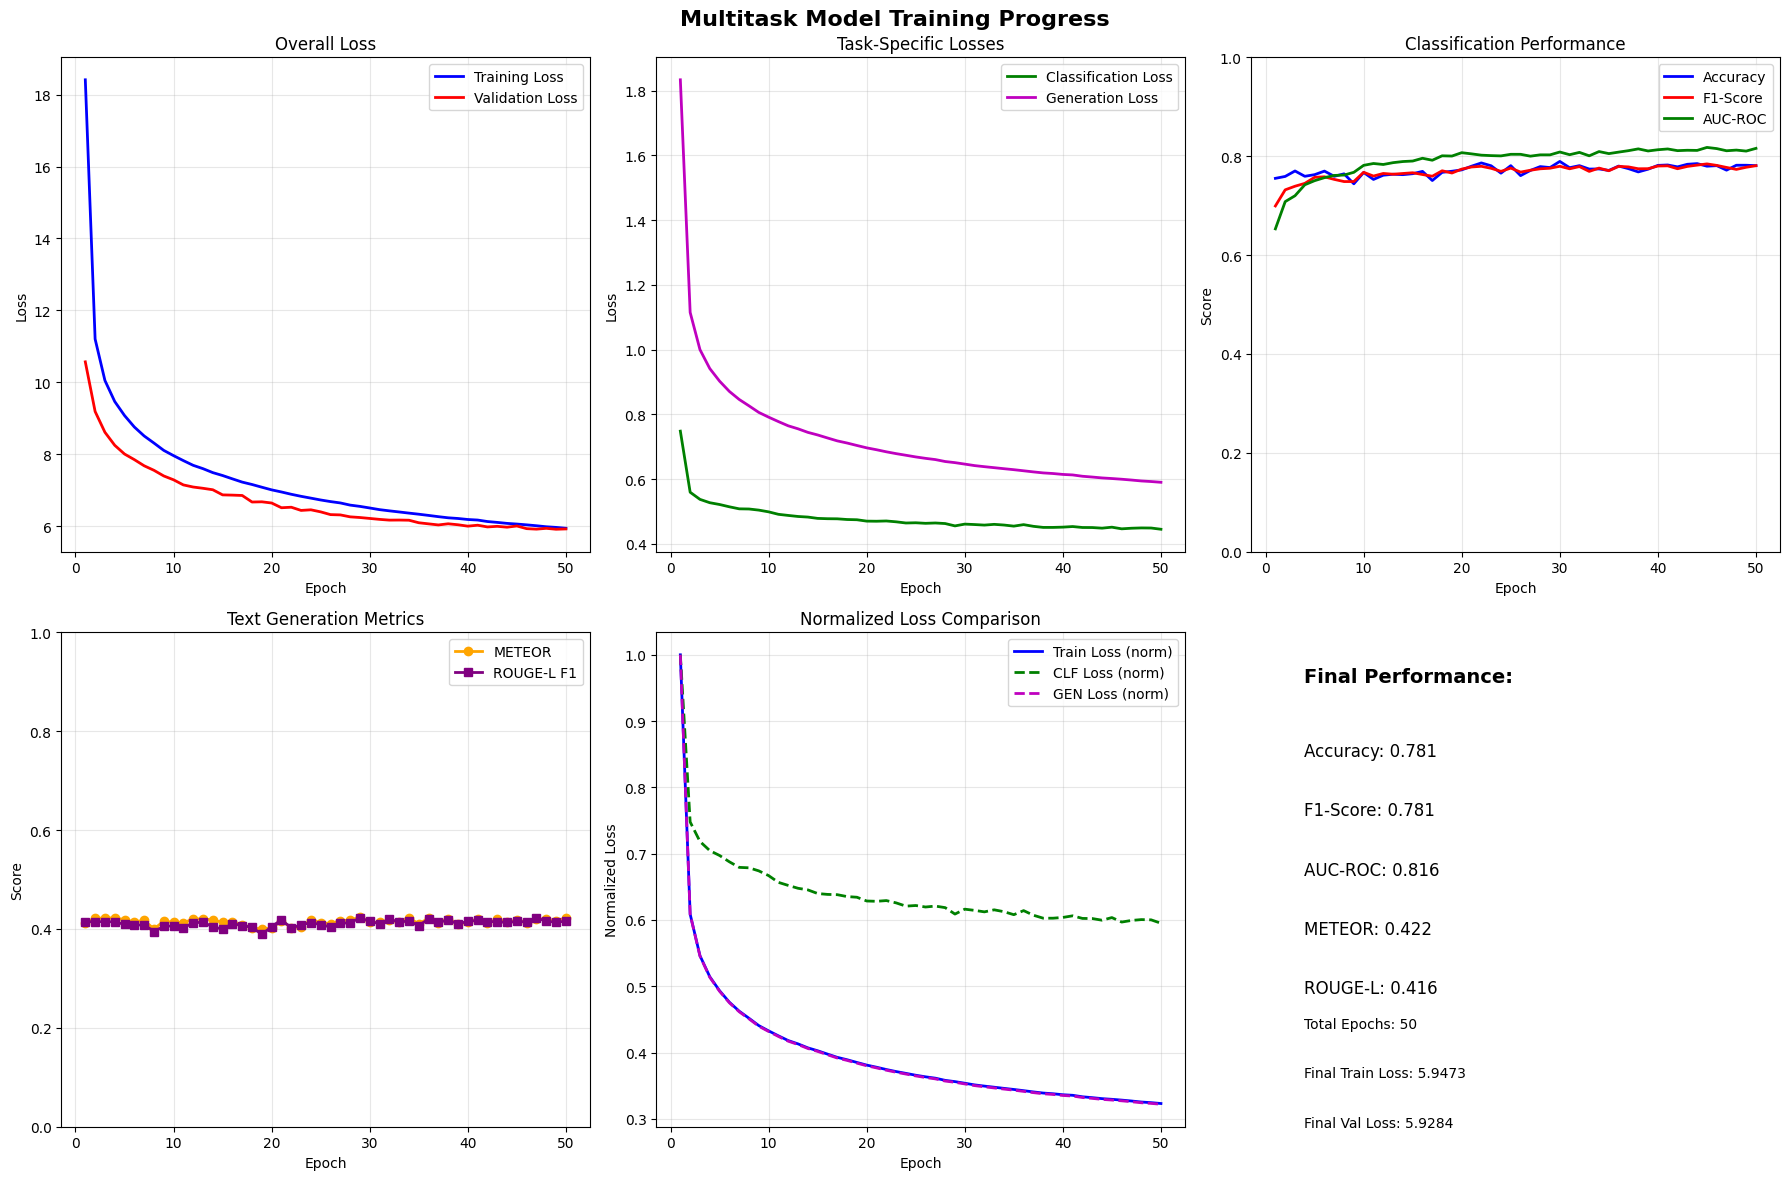


TRAINING SUMMARY
Best Accuracy: 0.7895
Best F1-Score: 0.7845
Best AUC-ROC: 0.8178
Best METEOR: 0.4236
Best ROUGE-L: 0.4228


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.8818
Classification metrics (all 3625 samples):
  Accuracy     : 0.7942
  F1-Score     : 0.7932
  Sensitivity  : 0.8687
  Specificity  : 0.5605
  AUC-ROC      : 0.8303

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4160
  METEOR       : 0.4228

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor and
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. I advise regular self-examination and a repeat breast scan measurement in one year. In case of palpable, visible changes or persistent pain, I recommend a clinical examination by a specialist doctor an

## Cross Attention and Minimal Text

### Initialise Model

In [11]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='attention',         
    projection_type='attention',         
    use_minimal_text=True,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: ATTENTION projection + MINIMAL text
Projection type: attention


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: attention
  Projection type: attention
  Minimal text: True
  Feature projection: Yes


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 19.1273
Classification loss: 0.7388
Generation loss: 1.9053
Weighted gen loss: 19.053403
Validation loss: 10.7515
Validation metrics:
  Accuracy     : 0.7461
  F1-Score     : 0.7087
  Sensitivity  : 0.9195
  Specificity  : 0.2030
  AUC-ROC      : 0.6818

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4036
  ✓ New best METEOR: 0.4036
  ROUGE-L F1   : 0.4184
  ✓ New best ROUGE-L F1: 0.4184
✓ New best accuracy: 0.7461
✓ New best F1: 0.7087
✓ New best AUC-ROC: 0.6818

Epoch 2/50
Training loss: 11.5802
Classification loss: 0.5516
Generation loss: 1.1525
Weighted gen loss: 11.525022
Validation loss: 9.4365
Validation metrics:
  Accuracy     : 0.7522
  F1-Score     : 0.7240
  Sensitivity  : 0.9094
  Specificity  : 0.2600
  AUC-ROC      : 0.7072

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best accuracy: 0.7724
✓ New best F1: 0.7631
✓ New best AUC-ROC: 0.7936

Epoch 17/50
Training loss: 7.4727
Classification loss: 0.4730
Generation loss: 0.7425
Weighted gen loss: 7.425389
Validation loss: 6.9620
Validation metrics:
  Accuracy     : 0.7506
  F1-Score     : 0.7548
  Sensitivity  : 0.8180
  Specificity  : 0.5393
  AUC-ROC      : 0.7900

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 18/50
Training loss: 7.4125
Classification loss: 0.4756
Generation loss: 0.7365
Weighted gen loss: 7.364973
Validation loss: 6.9211
Validation metrics:
  Accuracy     : 0.7597
  F1-Score     : 0.7645
  Sensitivity  : 0.8205
  Specificity  : 0.5690
  AUC-ROC      : 0.7926

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 sample

Validation loss: 6.2746
Validation metrics:
  Accuracy     : 0.7674
  F1-Score     : 0.7668
  Sensitivity  : 0.8489
  Specificity  : 0.5120
  AUC-ROC      : 0.8019

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.5765
Classification loss: 0.4586
Generation loss: 0.6531
Weighted gen loss: 6.530657
Validation loss: 6.2377
Validation metrics:
  Accuracy     : 0.7685
  F1-Score     : 0.7702
  Sensitivity  : 0.8402
  Specificity  : 0.5439
  AUC-ROC      : 0.8031

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 35/50
Training loss: 6.5383
Classification loss: 0.4538
Generation loss: 0.6493
Weighted gen loss: 6.492947
Validation loss: 6.2314
Val

Training loss: 6.1432
Classification loss: 0.4445
Generation loss: 0.6099
Weighted gen loss: 6.098770
Validation loss: 5.9946
Validation metrics:
  Accuracy     : 0.7759
  F1-Score     : 0.7776
  Sensitivity  : 0.8449
  Specificity  : 0.5599
  AUC-ROC      : 0.8156

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145


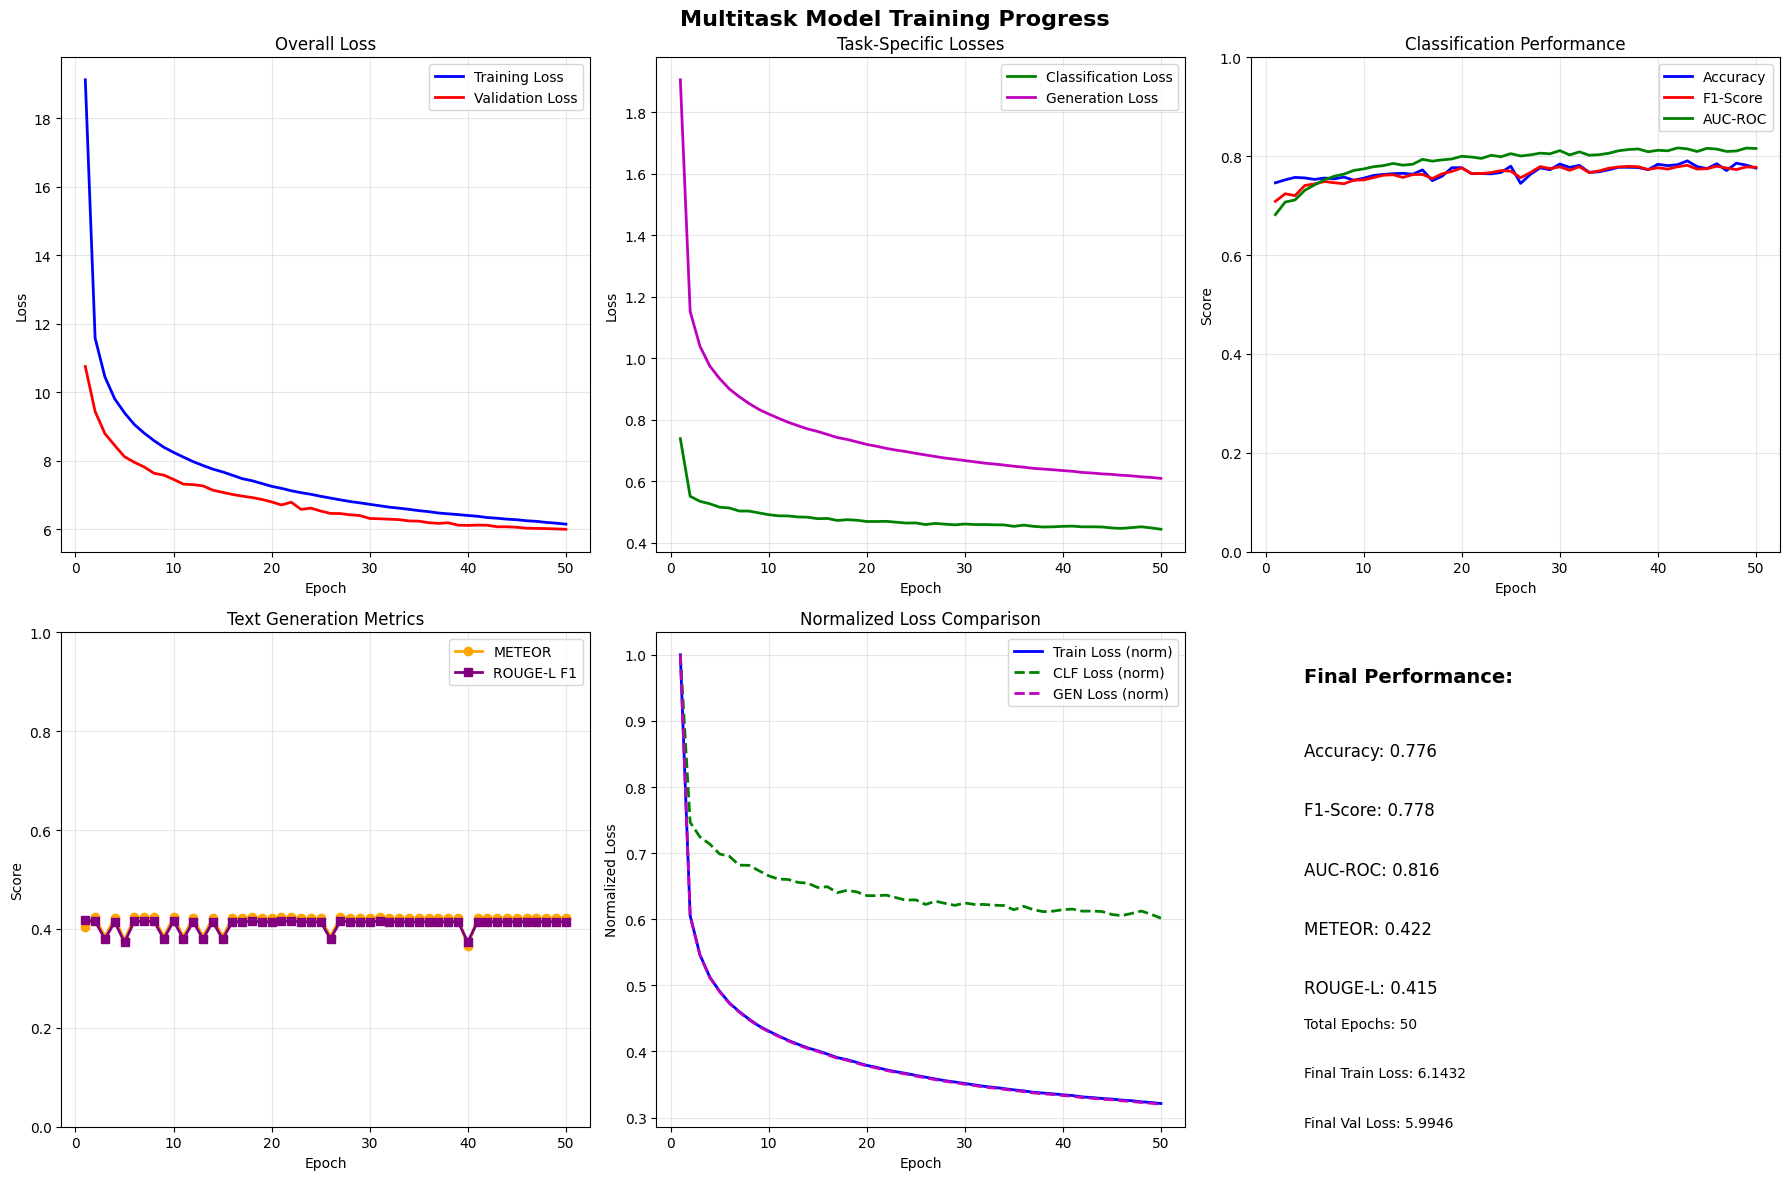


TRAINING SUMMARY
Best Accuracy: 0.7906
Best F1-Score: 0.7816
Best AUC-ROC: 0.8167
Best METEOR: 0.4236
Best ROUGE-L: 0.4184


In [12]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [13]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.9471
Classification metrics (all 3625 samples):
  Accuracy     : 0.8011
  F1-Score     : 0.8014
  Sensitivity  : 0.8672
  Specificity  : 0.5936
  AUC-ROC      : 0.8346

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4130
  METEOR       : 0.4206

Sample efficiency: 3625/3625 samples used for text metrics


In [14]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor and
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a

In [13]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='attention',         
    projection_type='attention',         
    use_minimal_text=True,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: ATTENTION projection + MINIMAL text
Projection type: attention
Using device: cuda
Model configuration:
  Projection mode: attention
  Projection type: attention
  Minimal text: True
  Feature projection: Yes



Epoch 1/50
Training loss: 19.3887
Classification loss: 0.6890
Generation loss: 1.9320
Weighted gen loss: 19.319766
Validation loss: 10.6385
Validation metrics:
  Accuracy     : 0.7588
  F1-Score     : 0.6964
  Sensitivity  : 0.9640
  Specificity  : 0.1163
  AUC-ROC      : 0.6880
✓ New best accuracy: 0.7588
✓ New best F1: 0.6964
✓ New best AUC-ROC: 0.6880

Epoch 2/50
Training loss: 11.4955
Classification loss: 0.5458
Generation loss: 1.1441
Weighted gen loss: 11.440958
Validation loss: 9.3655
Validation metrics:
  Accuracy     : 0.7682
  F1-Score     : 0.7388
  Sensitivity  : 0.9257
  Specificity  : 0.2748
  AUC-ROC      : 0.7355
✓ New best accuracy: 0.7682
✓ New best F1: 0.7388
✓ New best AUC-ROC: 0.7355

Epoch 3/50
Training loss: 10.3943
Classification loss: 0.5334
Generation loss: 1.0341
Weighted gen loss: 10.340991
Validation loss: 8.7555
Validation metrics:
  Accuracy     : 0.7597
  F1-Score     : 0.7445
  Sensitivity  : 0.8879
  Specificity  : 0.3580
  AUC-ROC      : 0.7386
✓ New

Training loss: 6.8967
Classification loss: 0.4630
Generation loss: 0.6850
Weighted gen loss: 6.850431
Validation loss: 6.5393
Validation metrics:
  Accuracy     : 0.7732
  F1-Score     : 0.7676
  Sensitivity  : 0.8711
  Specificity  : 0.4664
  AUC-ROC      : 0.7982

Epoch 27/50
Training loss: 6.8453
Classification loss: 0.4629
Generation loss: 0.6799
Weighted gen loss: 6.798962
Validation loss: 6.4926
Validation metrics:
  Accuracy     : 0.7732
  F1-Score     : 0.7731
  Sensitivity  : 0.8507
  Specificity  : 0.5302
  AUC-ROC      : 0.8051
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 28/50
Training loss: 6.7986
Classification loss: 0.4575
Generation loss: 0.6753
Weighted gen loss: 6.752848
Validation loss: 6.3763
Validation metrics:
  Accuracy     : 0.7707
  F1-Score     : 0.7746
  Sensitivity  : 0.8311
  Specificity  : 0.5815
  AUC-ROC      : 0.8098
✓ New best AUC-ROC: 0.8098

Epoch 29/50
Training loss: 6.7551
Classification loss: 0.4592
Generation loss: 0.6709
Weighted gen lo

/home/s2080063/MWR-to-Text/model_projections.py:990: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


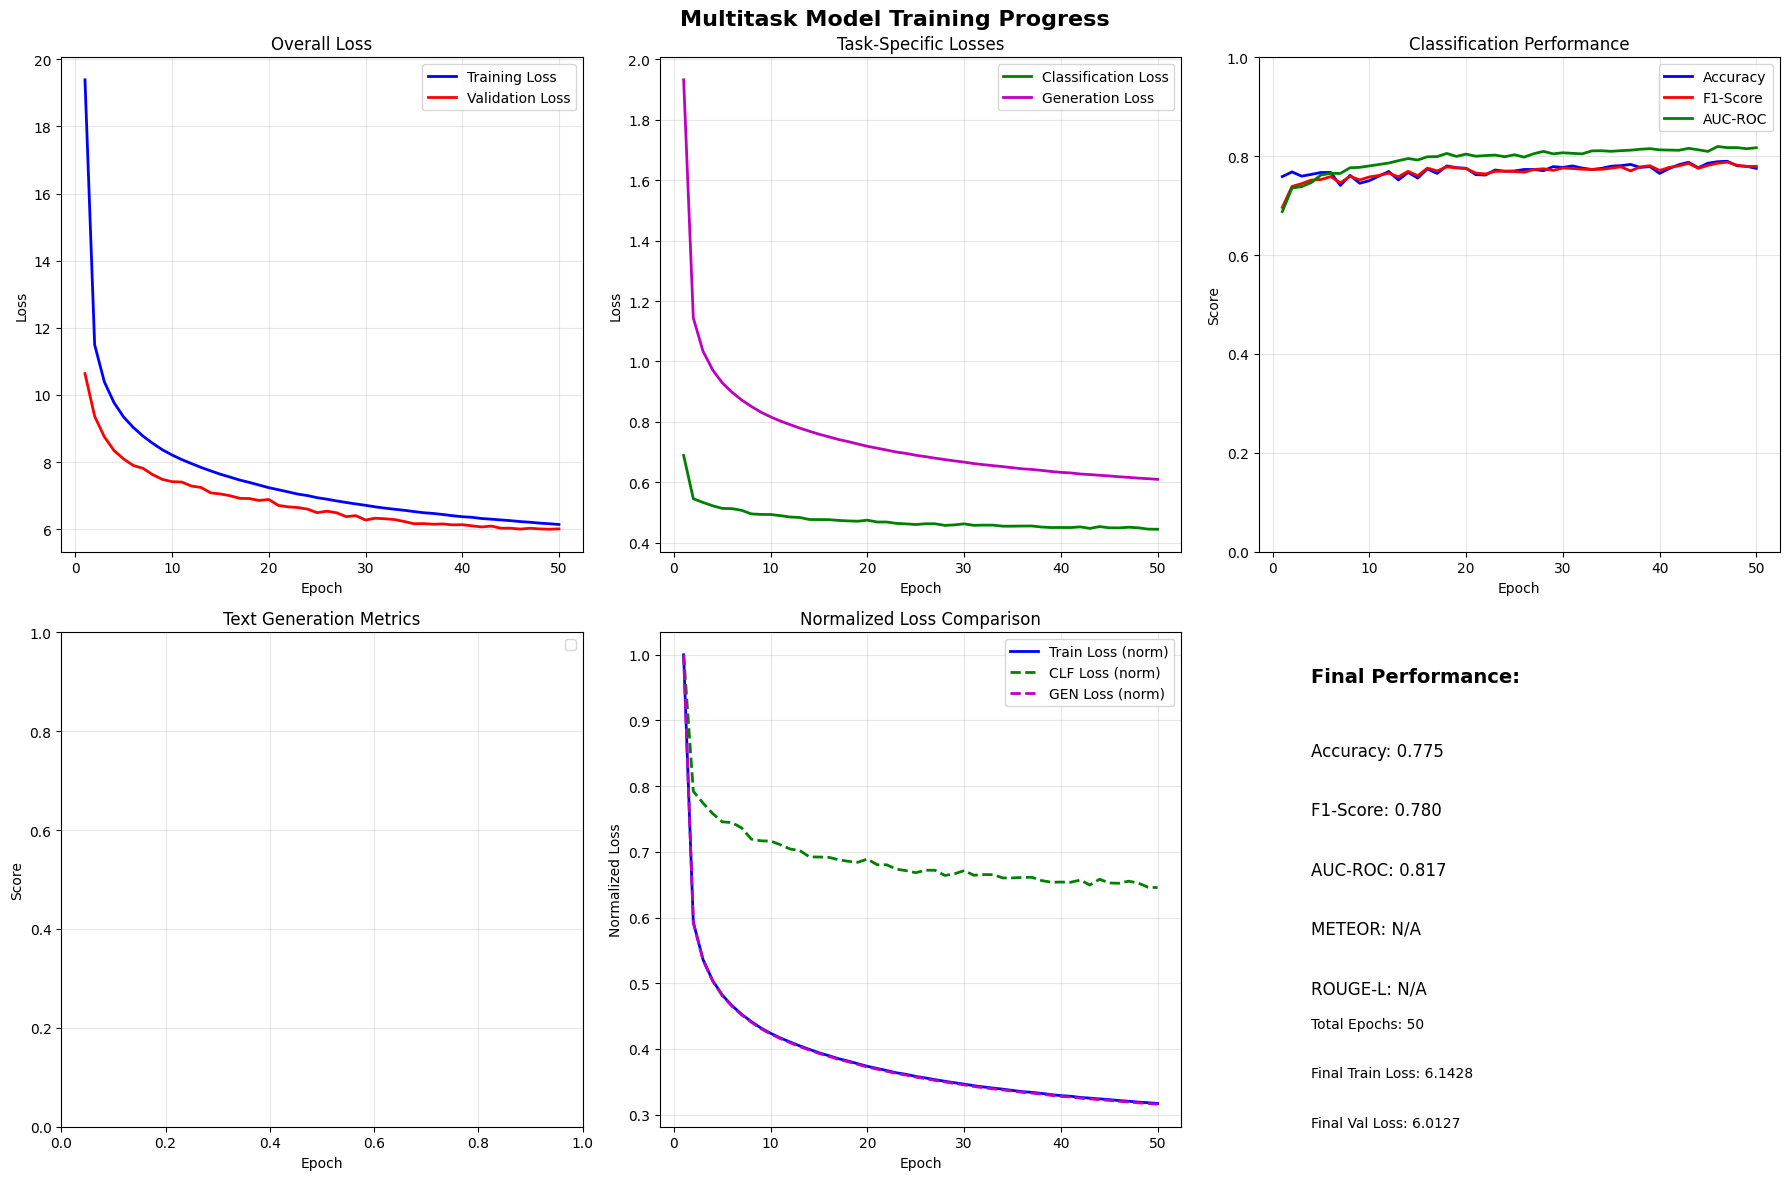


TRAINING SUMMARY
Best Accuracy: 0.7897
Best F1-Score: 0.7880
Best AUC-ROC: 0.8196


In [14]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [15]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.9644
Classification metrics (all 3625 samples):
  Accuracy     : 0.7898
  F1-Score     : 0.7939
  Sensitivity  : 0.8410
  Specificity  : 0.6290
  AUC-ROC      : 0.8363

2. Sampled Text Generation Performance:
=== ENCODER EMBEDDING DIAGNOSTIC ===
Embedding variance: 0.243898
Embedding std: 0.478481
Embedding range: 3.740929
Cosine similarity between samples 0 and 1: 0.419075
First 2 samples, first 5 dims:
tensor([[0.0000, 0.0000, 0.0000, 0.1862, 0.0000],
        [1.0681, 0.0000, 0.0000, 0.2645, 0.3256]], device='cuda:0')
=== END DIAGNOSTIC ===

Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3018
  METEOR       : 0.2779

Sample efficiency: 3625/3625 samples used for text metrics


In [16]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 380
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate signs of locally elevated metabolism in the breast breast. A follow-up is recommended in 1 year (November 2014). during this period, we advise monthly self-exa, and a recommended breast check in 6 months ( ( in a
Reference : The measured temperature values are exceeded, but the current distribution of larger markers of locally higher metabolism in breast tissue does not indicate.
----------------------------------------

Sample 1557
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast breast. We recommend the next check-up in 1 year (02. 2018). during the period of the period, we advise regular self-examination. in the case of a typical characteristic changes, or a abnormal abnormal abnormal abn

In [9]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='attention',         
    projection_type='attention',         
    use_minimal_text=False,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: ATTENTION projection + FULL text
Projection type: attention


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: attention
  Projection type: attention
  Minimal text: False
  Feature projection: Yes



Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 18.4092
Classification loss: 0.7482
Generation loss: 1.8334
Weighted gen loss: 18.334368
Validation loss: 10.5718
Validation metrics:
  Accuracy     : 0.7552
  F1-Score     : 0.6994
  Sensitivity  : 0.9530
  Specificity  : 0.1357
  AUC-ROC      : 0.6531
✓ New best accuracy: 0.7552
✓ New best F1: 0.6994
✓ New best AUC-ROC: 0.6531

Epoch 2/50
Training loss: 11.2743
Classification loss: 0.5607
Generation loss: 1.1218
Weighted gen loss: 11.218197
Validation loss: 9.3115
Validation metrics:
  Accuracy     : 0.7533
  F1-Score     : 0.7113
  Sensitivity  : 0.9330
  Specificity  : 0.1904
  AUC-ROC      : 0.6774
✓ New best F1: 0.7113
✓ New best AUC-ROC: 0.6774

Epoch 3/50
Training loss: 10.1462
Classification loss: 0.5384
Generation loss: 1.0092
Weighted gen loss: 10.092324
Validation loss: 8.6651
Validation metrics:
  Accuracy     : 0.7522
  F1-Score     : 0.7232
  Sensitivity  : 0.9108
  Specificity  : 0.2554
  AUC-ROC      : 0.7016
✓ New best F1: 0.7232
✓ New best AUC-ROC: 0.7

Training loss: 6.6917
Classification loss: 0.4666
Generation loss: 0.6645
Weighted gen loss: 6.645077
Validation loss: 6.4303
Validation metrics:
  Accuracy     : 0.7801
  F1-Score     : 0.7722
  Sensitivity  : 0.8839
  Specificity  : 0.4550
  AUC-ROC      : 0.7999
✓ New best accuracy: 0.7801

Epoch 27/50
Training loss: 6.6596
Classification loss: 0.4640
Generation loss: 0.6613
Weighted gen loss: 6.613222
Validation loss: 6.2660
Validation metrics:
  Accuracy     : 0.7740
  F1-Score     : 0.7675
  Sensitivity  : 0.8748
  Specificity  : 0.4584
  AUC-ROC      : 0.7979
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 28/50
Training loss: 6.6062
Classification loss: 0.4613
Generation loss: 0.6560
Weighted gen loss: 6.560048
Validation loss: 6.3469
Validation metrics:
  Accuracy     : 0.7784
  F1-Score     : 0.7751
  Sensitivity  : 0.8671
  Specificity  : 0.5006
  AUC-ROC      : 0.8040
✓ New best F1: 0.7751
✓ New best AUC-ROC: 0.8040

Epoch 29/50
Training loss: 6.5570
Classification lo

/home/s2080063/MWR-to-Text/model_projections.py:990: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


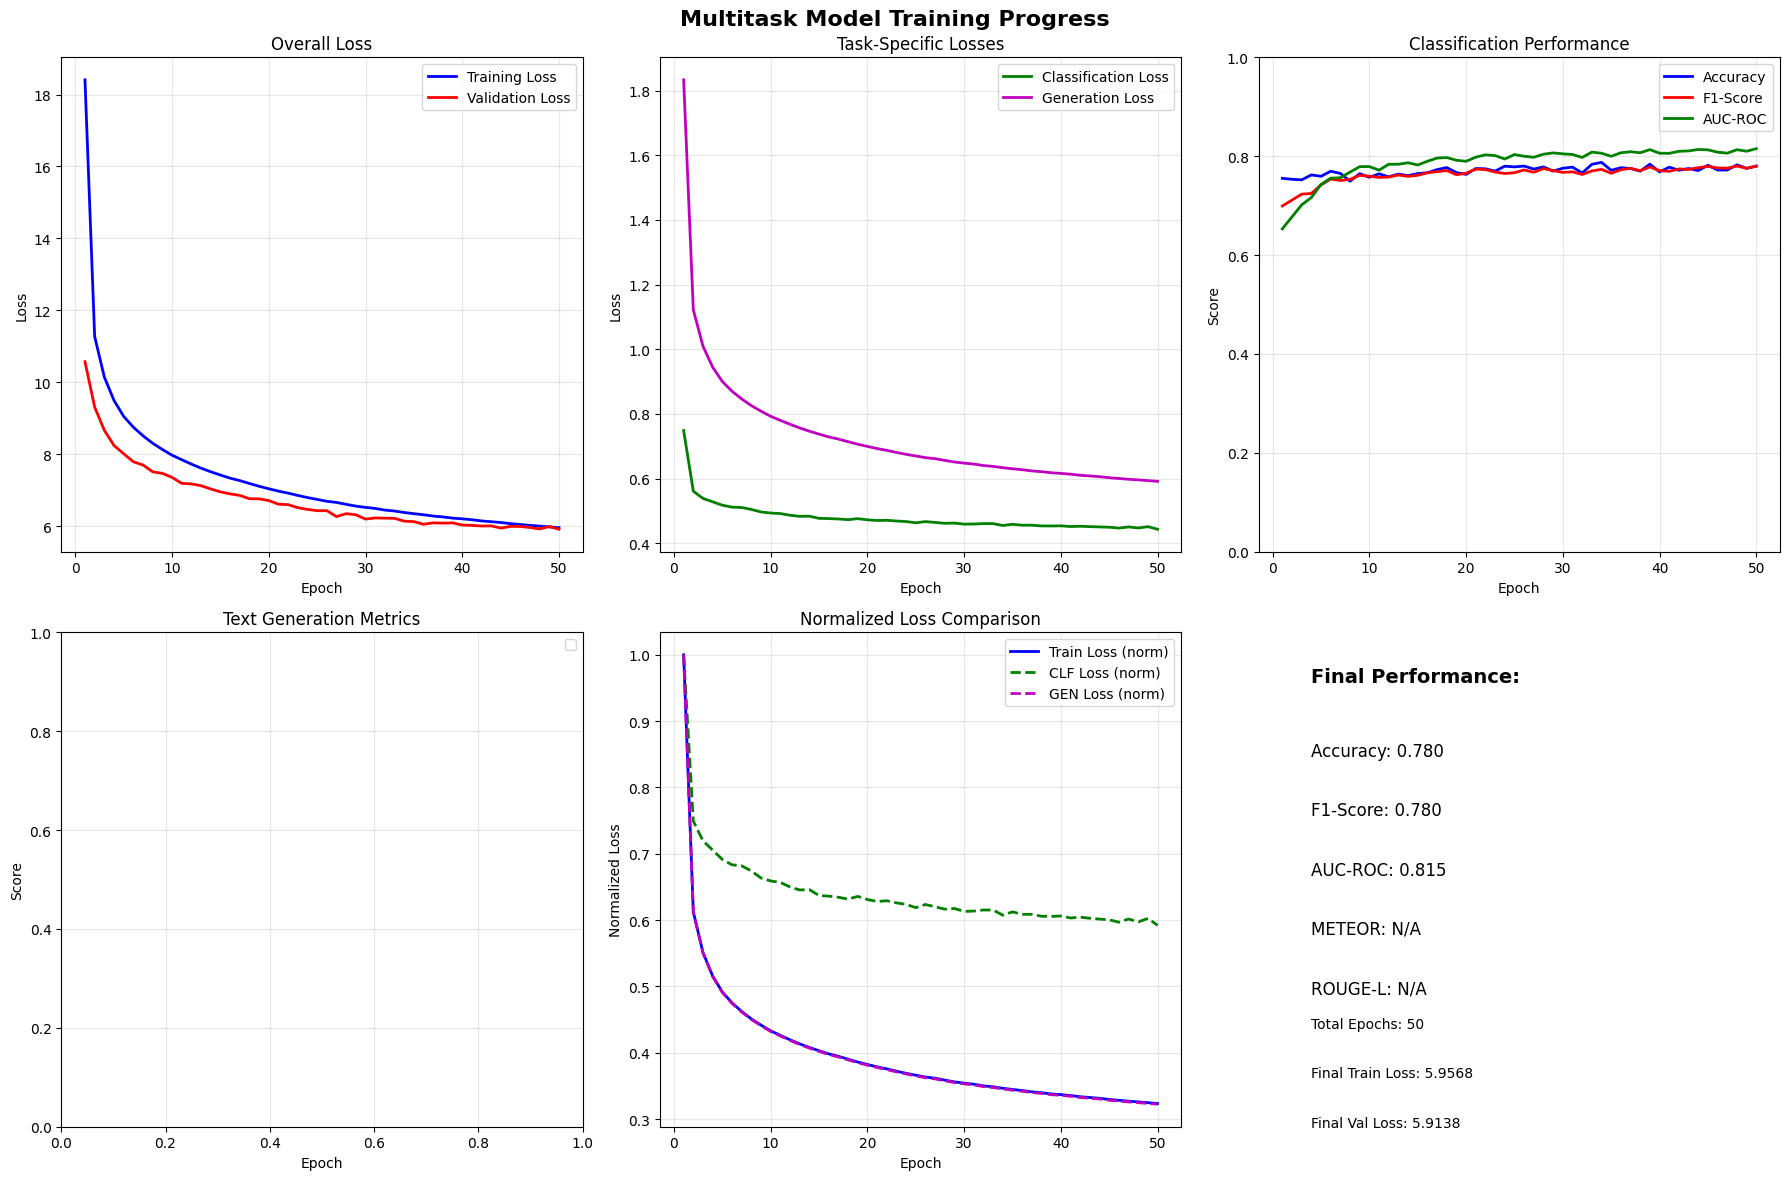


TRAINING SUMMARY
Best Accuracy: 0.7875
Best F1-Score: 0.7802
Best AUC-ROC: 0.8152


In [10]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [11]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.8624
Classification metrics (all 3625 samples):
  Accuracy     : 0.7967
  F1-Score     : 0.7961
  Sensitivity  : 0.8687
  Specificity  : 0.5708
  AUC-ROC      : 0.8355

2. Sampled Text Generation Performance:
=== ENCODER EMBEDDING DIAGNOSTIC ===
Embedding variance: 0.250703
Embedding std: 0.485322
Embedding range: 4.671562
Cosine similarity between samples 0 and 1: 0.369687
First 2 samples, first 5 dims:
tensor([[0.0000, 0.1083, 0.0000, 1.9698, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]], device='cuda:0')
=== END DIAGNOSTIC ===

Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3785
  METEOR       : 0.3717

Sample efficiency: 3625/3625 samples used for text metrics


In [12]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, slightly above the recommended value, but currently shows no signs of locally increased metabolism in the breast tissue. We recommend a follow-up check in one year (09.2014). During this period, we advise monthly self-examinations. In case of
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend the next check-up in 1 year (October 2017). During this period, we advise regular self-examination. In case of noticeable, visible changes, discharge, or prolonged pain, please seek an earlier check
Reference : The m